In [96]:
"""
Will Buesnel, Jul 26.

Workflow to test different kernels for the Gaussian process regression of parameters, and visualise the uncertainty in the parameter predictions.

Generally going to be using the pyro docs tutorial on Gaussian process as a reference: https://pyro.ai/examples/gp.html
I'm going to change it, because my gpr only models the uncertainty, not the global value.
"""

"\nWill Buesnel, Jul 26.\n\nWorkflow to test different kernels for the Gaussian process regression of parameters, and visualise the uncertainty in the parameter predictions.\n\nGenerally going to be using the pyro docs tutorial on Gaussian process as a reference: https://pyro.ai/examples/gp.html\nI'm going to change it, because my gpr only models the uncertainty, not the global value.\n"

In [97]:

import os
import matplotlib.pyplot as plt
import torch
import numpy as np

import matplotlib as mpl

import matplotlib as mpl

mpl.rcParams["axes.labelsize"] = 18      # x and y axis labels
mpl.rcParams["xtick.labelsize"] = 16     # x-axis tick labels
mpl.rcParams["ytick.labelsize"] = 16     # y-axis tick labels
mpl.rcParams["legend.fontsize"] = 16   # legend text
mpl.rcParams["legend.title_fontsize"] = 18
mpl.rcParams["axes.titlesize"] = 20      # plot title

import pyro
import pyro.contrib.gp as gp
import pyro.distributions as dist

from matplotlib.animation import FuncAnimation
from mpl_toolkits.axes_grid1 import make_axes_locatable

import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from pathlib import Path
import sys

# Add the project root to the Python path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.models.local_stats import GibbsKernel
import matplotlib.pyplot as plt
import pandas as pd

from src.models.parameters import get_all_parameter_interpolants

from typing import Callable

In [98]:
assert pyro.__version__.startswith('1.9.1')
pyro.set_rng_seed(0)
torch.set_default_dtype(torch.float64)

In [99]:
# note that this helper function does three different things:
# (i) plots the observed data;
# (ii) plots the predictions from the learned GP after conditioning on data;
# (iii) plots samples from the GP prior (with no conditioning on observed data)


def plot(
    plot_observed_data=False,
    plot_predictions=False,
    n_prior_samples=0,
    gpr=None,
    interp: Callable = lambda x: 0.0,
    kernel=None,
    n_test=100,

    ax=None,
):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))

    if plot_predictions:
        Xtest = torch.linspace(X.min().item(), X.max().item(), n_test)  # test inputs
        # compute predictive mean and variance
        with torch.no_grad():
            if type(gpr) == gp.models.VariationalSparseGP:
                mean, cov = gpr(Xtest, full_cov=True)
            else:
                mean, cov = gpr(Xtest, full_cov=True, noiseless=False)
        sd = cov.diag().sqrt()  # standard deviation at each input point x
        ax.plot(Xtest.numpy(), mean.numpy(), "r", lw=2)  # plot the mean
        ax.fill_between(
            Xtest.numpy(),  # plot the two-sigma uncertainty about the mean
            (mean - 2.0 * sd).numpy(),
            (mean + 2.0 * sd).numpy(),
            color="C0",
            alpha=0.3,
        )
    if n_prior_samples > 0:  # plot samples from the GP prior
        Xtest = torch.linspace(X.min().item(), X.max().item(), n_test)  # test inputs
        noise = (
            gpr.noise
            if type(gpr) != gp.models.VariationalSparseGP
            else gpr.likelihood.variance
        )
        cov = kernel.forward(Xtest) + noise.expand(n_test).diag()
        samples = dist.MultivariateNormal(
            torch.zeros(n_test), covariance_matrix=cov
        ).sample(sample_shape=(n_prior_samples,))
        y_vals = samples.numpy() + interp(Xtest).numpy()

        #ax.plot(Xtest.numpy(), y_vals.T, lw=2, alpha=0.4, label="GP prior samples")
    xlim = Xtest.min().item(), Xtest.max().item() if Xtest is not None else (-0.5, 5.5)

    '''
    #plot the original line for reference:
    plt.plot(X.numpy(), Y.numpy(), "kx", label="Observed (fitted parameters) data")
    # plot interpolated values for reference:
    plt.plot(X.numpy(), interp(X).numpy(), "b--", label="Interpolated values")
    plt.xlabel("SOC")
    plt.ylabel("Parameter prediction")
    '''
    '''
    fig= plt.figure(figsize=(12, 6))
    fig.suptitle("GP prior noise samples")
    plt.title(f"Kernel: {type(kernel).__name__}, variance={var}, lengthscale={lengthscale}, noise={noise}")
    plt.plot(Xtest.numpy(), samples.T, lw=2, alpha=0.4)
    # add a line at zero error:
    plt.axhline(0, color="k", linestyle="--", label="Zero error")
    plt.xlabel("SOC")
    plt.ylabel("Error in parameter prediction")
    '''
    # plot mean absolute error at each point:
    means = torch.mean(torch.abs(samples), dim=0)

    plt.figure(figsize=(12, 6))
    plt.title(f"Mean absolute error at each point, Kernel: {type(kernel).__name__}, variance={var}, lengthscale={lengthscale}, noise={noise}")
    plt.plot(Xtest.numpy(), means.numpy(), lw=2, alpha=0.4)
    plt.xlabel("SOC")
    plt.ylabel("Mean absolute error in parameter prediction")



In [100]:
# get data from paramscsv. Need to start one level higher than cwd

params_df = pd.read_csv(os.path.join(project_root, "data", "processed", "MLP001_params.csv"))
ocv_df = pd.read_csv(os.path.join(project_root, "data", "processed", "MLP001_ocv.csv"))

interpolants = get_all_parameter_interpolants(params_df, ocv_df, method="clough_tocher")

# X will be just the r0 values, and for now just soc.
# for this, we will also just use the values at 25 deg

x_df = params_df[params_df["Temperature_degC"] == 25]["SOC"].dropna()
y_df = params_df[params_df["Temperature_degC"] == 25]["R0 [Ohm]"].dropna()

# drop the first and last values of x_df and y_df, because they are outliers and will mess up the GP regression. This is because the GP regression is very sensitive to outliers, and we want to test the kernels on the "normal" data.
x_df = x_df
y_df = y_df

X = torch.tensor(x_df.to_numpy(), dtype=torch.float32)
Y = torch.tensor(y_df.to_numpy(), dtype=torch.float32)


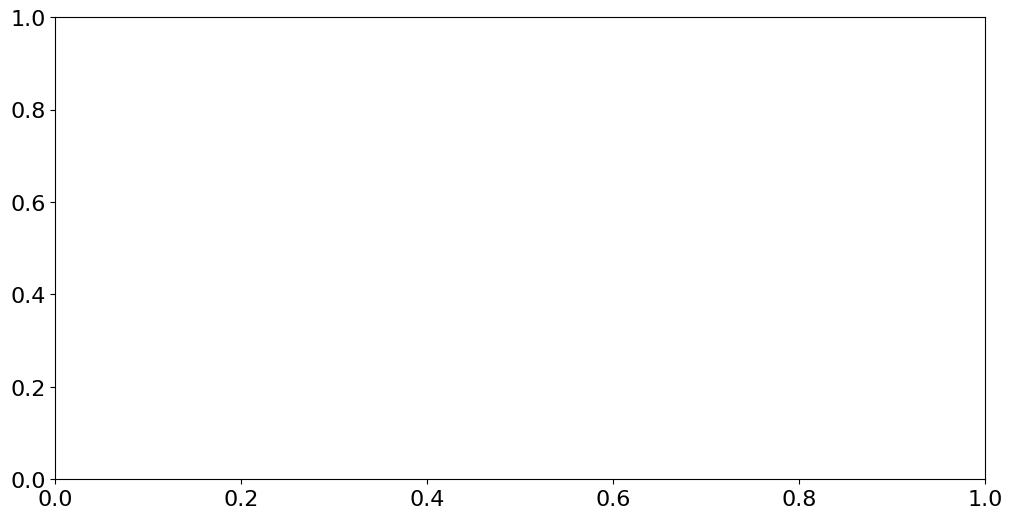

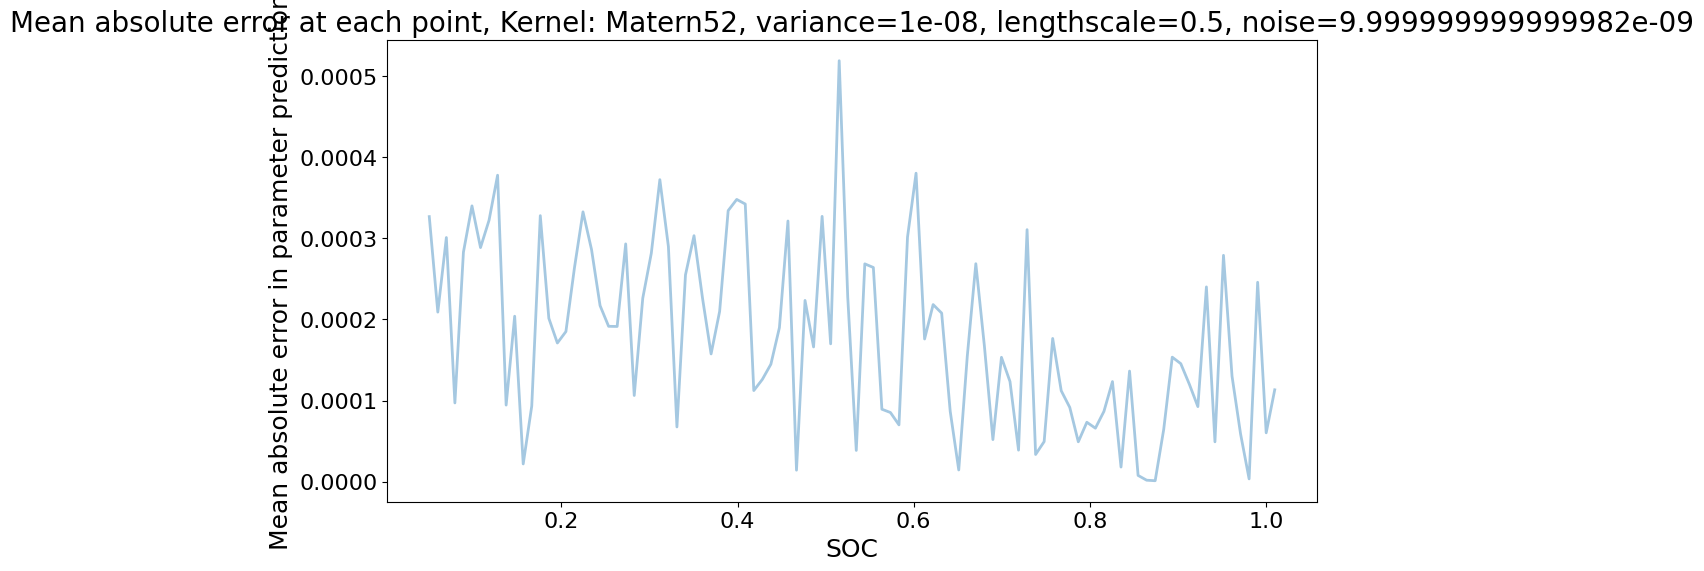

In [101]:
# try implement a matern kernel.

var = 0.00000001
noise = 0.00000001
lengthscale = 0.5
kernel = gp.kernels.Matern52(input_dim=1, variance=torch.tensor(var), lengthscale=torch.tensor(lengthscale))

gpr = gp.models.GPRegression(X, Y, kernel, noise=torch.tensor(noise))
# plot the GP prior function.
  # the actual model is the interpolated value + GP(mean=interpolated value, kernel=kernel)
# remake the interpolant function to only take SoC here, keeping temp at 25


interp_r0 = lambda x: torch.tensor(interpolants["R0 [Ohm]"](x.numpy(), 25.0), dtype=torch.float32)

plot(gpr=gpr, kernel=kernel, n_prior_samples=1, interp=interp_r0)




Text(0.5, 1.0, 'Kernel: GibbsKernel, noise=1e-08')

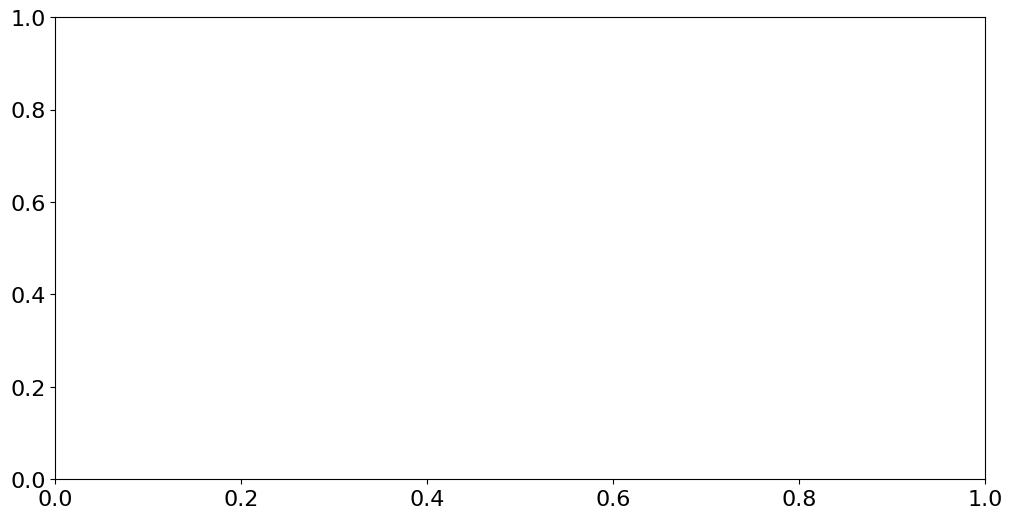

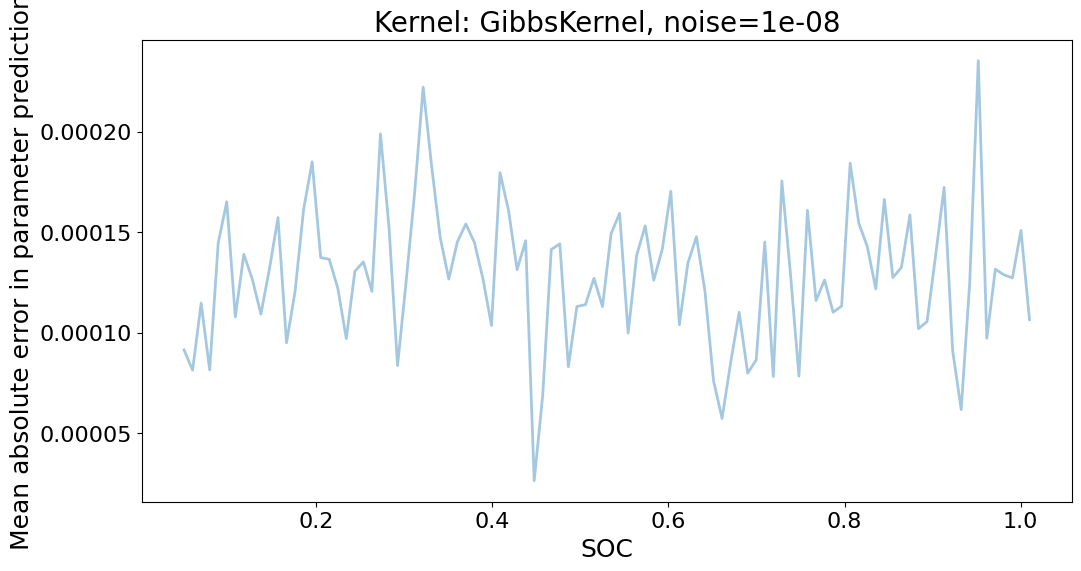

In [102]:
# now try with a Gibbs kernel, which is a non-stationary kernel. This will allow the lengthscale to vary with the input, which is what we want for our model.
from src.models.local_stats import generate_length_scale_function1
lengthscale_func = generate_length_scale_function1(X, Y, ell_min=0.01, ell_max=0.3, roughness=1000, spline_s=0.01)

kernel = GibbsKernel(input_dim=1, lengthscale_fn=lengthscale_func, variance=torch.tensor(var))
gprgibbs = gp.models.GPRegression(X, Y, kernel, noise=torch.tensor(noise))


plot(gpr=gprgibbs, kernel=kernel, n_prior_samples=5, interp=interp_r0)
plt.title(f"Kernel: {type(kernel).__name__}, noise={noise}")




Text(0, 0.5, 'Lengthscale')

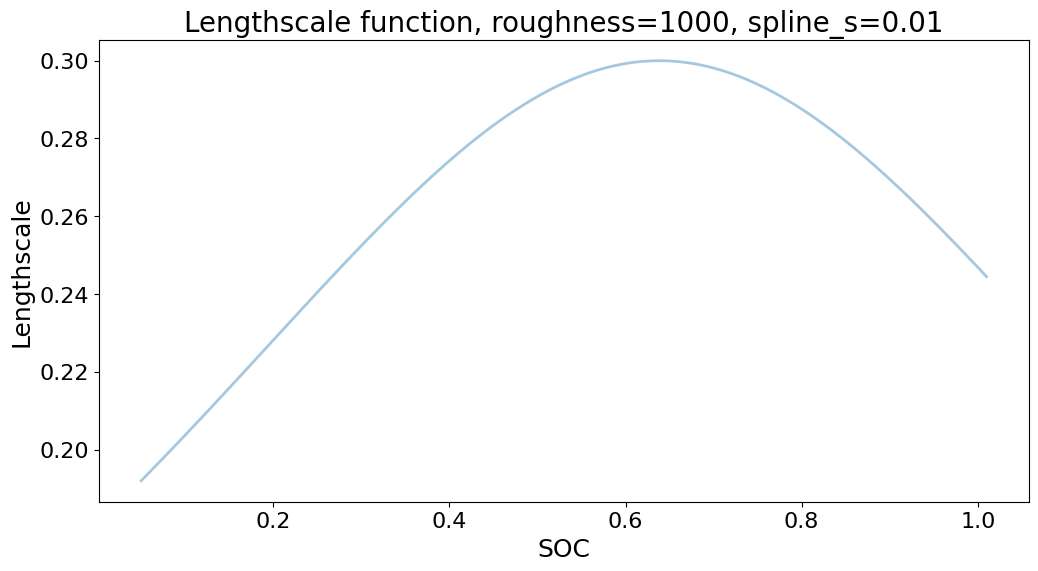

In [103]:
# plot the lengthscale function for diagnostic purposes:
x_test = torch.linspace(0.05, 1.01, 100).reshape(-1, 1)
lengthscale_values = lengthscale_func(x_test)
plt.figure(figsize=(12, 6))
plt.plot(x_test.numpy(), lengthscale_values.numpy(), lw=2, alpha=0.4)
plt.title(f"Lengthscale function, roughness={1000}, spline_s={0.01}")
plt.xlabel("SOC")
plt.ylabel("Lengthscale")

/var/folders/63/__1p4tt55zq_byscd0qttqcc0000gn/T/ipykernel_3968/3153055941.py:17: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  R = K / np.sqrt(outer(K.diag(), K.diag()))


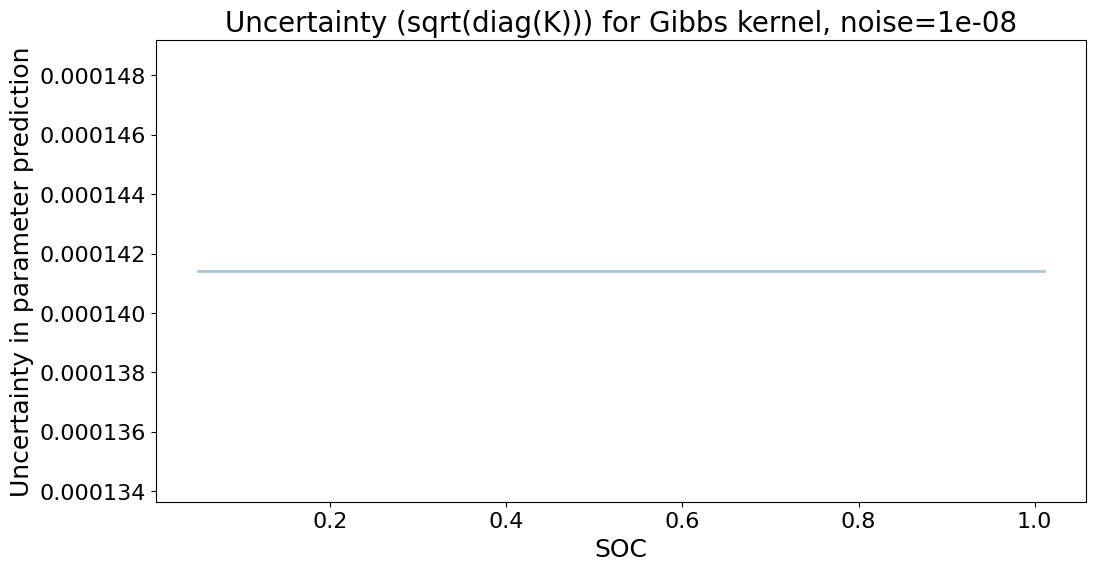

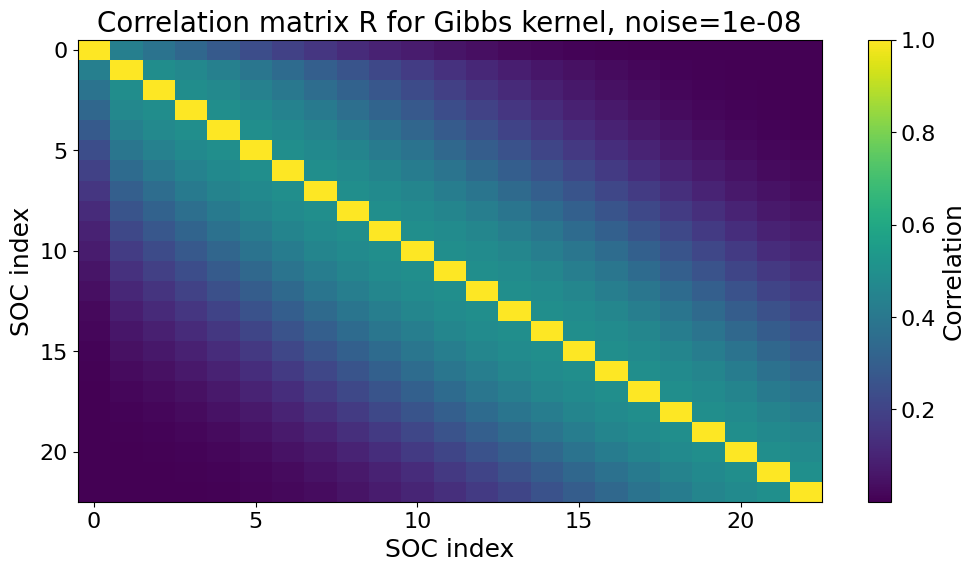

In [104]:
# plot sqrt(diag(K)) against SOC for the Gibbs kernel, to see how the uncertainty varies with SOC. This is a diagnostic plot to see if the Gibbs kernel is doing what we expect it to do.

from numpy import outer

with torch.no_grad():
    K = kernel.forward(X) + noise * torch.eye(X.shape[0])
    uncertainty = torch.sqrt(torch.diag(K))
    plt.figure(figsize=(12, 6))
    plt.plot(X.numpy(), uncertainty.numpy(), lw=2, alpha=0.4)
    plt.title(f"Uncertainty (sqrt(diag(K))) for Gibbs kernel, noise={noise}")
    plt.xlabel("SOC")
    plt.ylabel("Uncertainty in parameter prediction")

# visualise K for the Gibbs kernel, to see how the covariance varies with SOC. This is a diagnostic plot to see if the Gibbs kernel is doing what we expect it to do.
with torch.no_grad():
    K = kernel.forward(X) + noise * torch.eye(X.shape[0])
    R = K / np.sqrt(outer(K.diag(), K.diag()))
    plt.figure(figsize=(12, 6))
    plt.imshow(R.numpy(), cmap="viridis", aspect="auto")
    plt.colorbar(label="Correlation")
    plt.title(f"Correlation matrix R for Gibbs kernel, noise={noise}")
    plt.xlabel("SOC index")
    plt.ylabel("SOC index")

Text(0.5, 1.0, 'Correlation matrix R (fine grid) for Gibbs kernel')

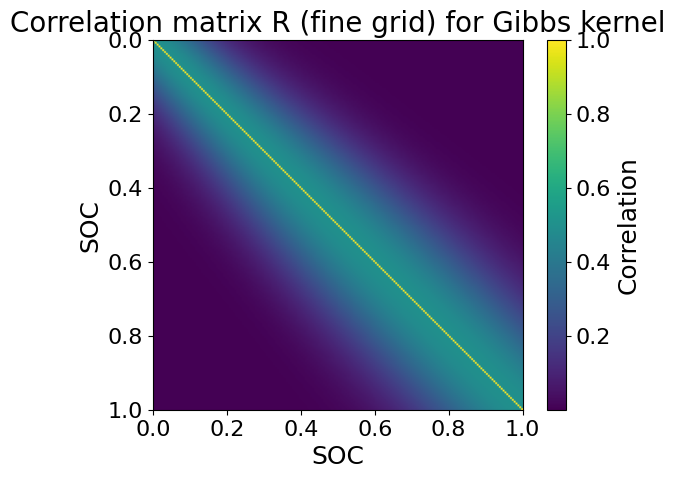

In [105]:
test_soc = torch.linspace(0.0, 1.0, 200).reshape(-1, 1)

def lengthscale_func(soc):
    return 0.10 + 0.1* torch.sigmoid(8 * (soc - 0.3))


def sigma(soc):
    sigma_min = 5e-5
    sigma_max = 5e-4
    centre = 0.25
    steepness = 12

    return sigma_min + (sigma_max - sigma_min) * (
        1 - torch.sigmoid(steepness * (soc-centre))
    )



kernel = GibbsKernel(input_dim=1, lengthscale_fn=lengthscale_func, variance=torch.tensor(var))

K = kernel.forward(test_soc) + noise * torch.eye(test_soc.shape[0])
R = K / torch.sqrt(torch.outer(torch.diag(K), torch.diag(K)))
L = sigma(test_soc).reshape(-1)
K = torch.outer(L, L) * R

plt.imshow(R.detach().numpy(), cmap="viridis", vmin=0.0001, vmax=1,
           extent=[0, 1, 1, 0])  # extent maps axes to actual SOC values
plt.xlabel("SOC"); plt.ylabel("SOC")
plt.colorbar(label="Correlation")
plt.title("Correlation matrix R (fine grid) for Gibbs kernel")

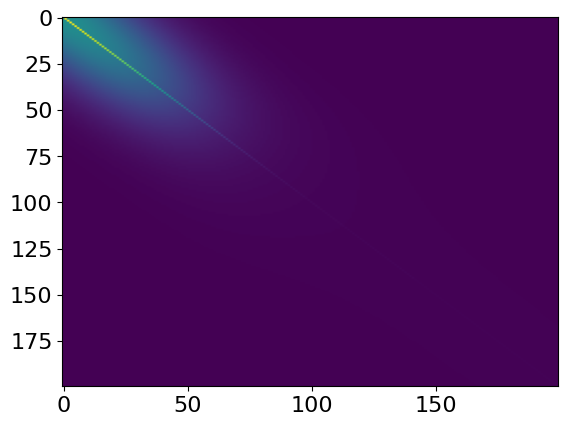

In [106]:
# plot uncertainty via K:
plt.imshow(K.detach().numpy(), cmap="viridis", aspect="auto")

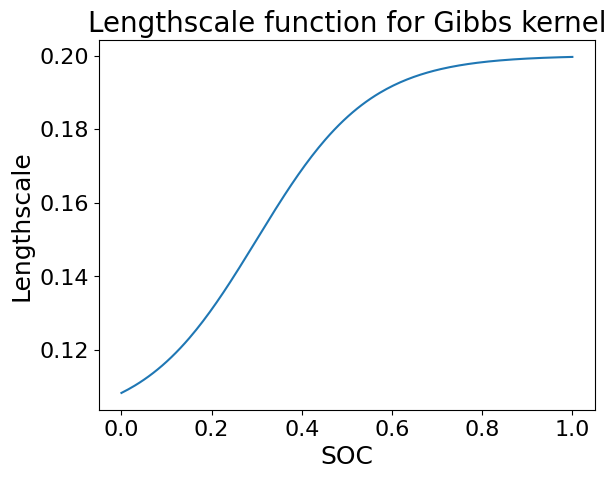

In [107]:
# plot lengthscale function of the test_soc.
lengthscales = kernel.lengthscale_fn(test_soc)
plt.plot(test_soc.numpy(), lengthscales.numpy())
plt.xlabel("SOC")
plt.ylabel("Lengthscale")
plt.title("Lengthscale function for Gibbs kernel")
plt.show()

In [108]:
test_soc = torch.linspace(0.1, 1.0, 200).reshape(-1, 1)
cov = kernel.forward(test_soc) + noise * torch.eye(test_soc.shape[0])
R = cov / torch.sqrt(torch.outer(torch.diag(cov), torch.diag(cov)))
L = 1.5*sigma(test_soc).reshape(-1)
cov = torch.outer(L, L) * R

samples = dist.MultivariateNormal(
    torch.zeros(len(test_soc)),
    covariance_matrix=cov,
).sample((len(test_soc),))


ys shape: torch.Size([200])
interp_vals shape: torch.Size([200])


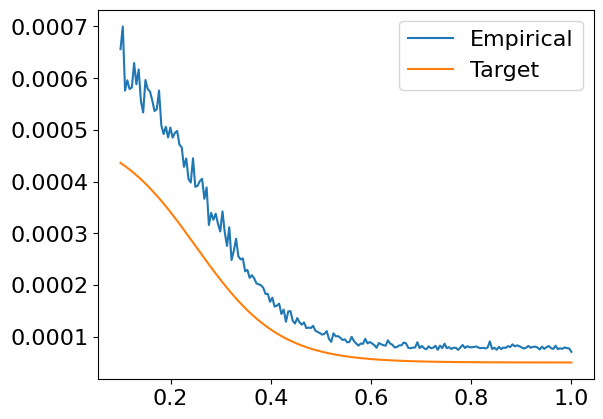

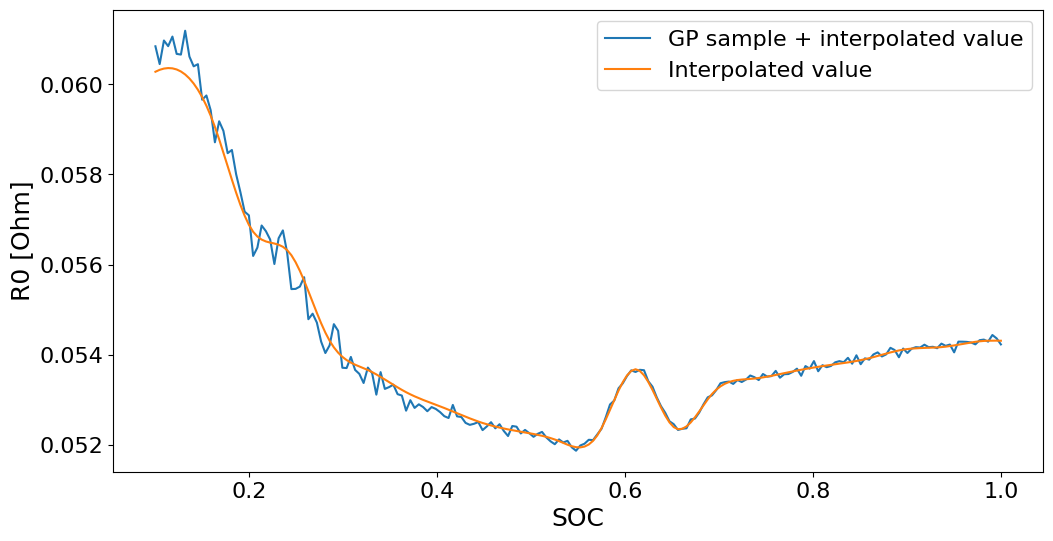

In [109]:
empirical_std = samples.std(dim=0)

plt.plot(test_soc, empirical_std, label="Empirical")
plt.plot(test_soc, sigma(test_soc), label="Target")
plt.legend()

# now plot the actual values we are getting for the overall func of r0 = ro(interp) + gp(0,K)
interp_vals = interp_r0(test_soc).squeeze(-1)
ys = samples[0] + interp_vals
print("ys shape:", ys.shape)
print("interp_vals shape:", interp_vals.shape)
plt.figure(figsize=(12, 6))
plt.plot(test_soc, ys, label="GP sample + interpolated value")
plt.plot(test_soc, interp_vals, label="Interpolated value")
plt.xlabel("SOC")
plt.ylabel("R0 [Ohm]")
plt.legend()

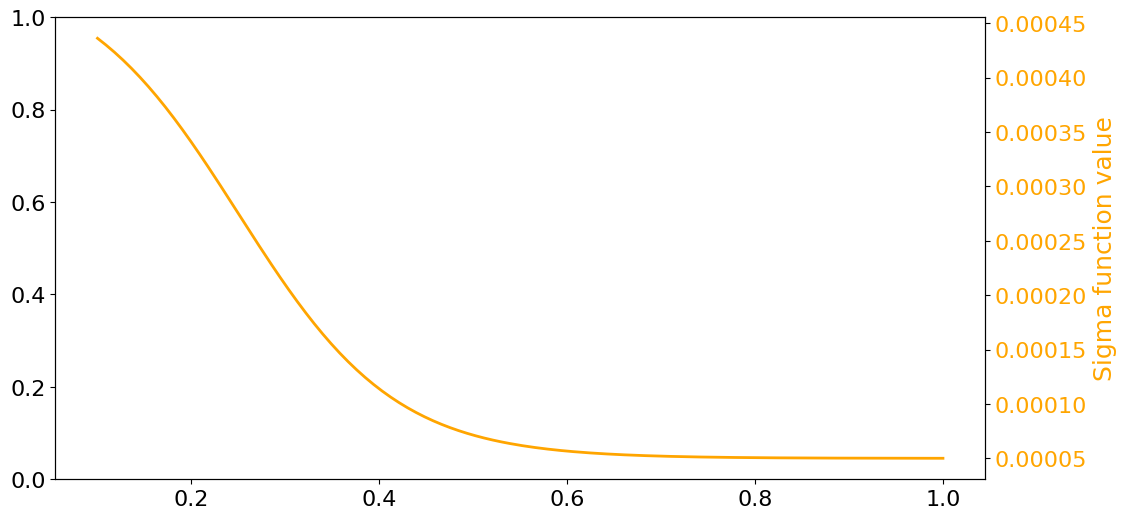

In [110]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# also plot the sigma function we are using for the Gibbs kernel, to see how the uncertainty varies with SOC.
# do this via a twin ax to avoid scaling issues with the GP prior samples and the sigma function.
ax2 = ax1.twinx()
ax2.plot(test_soc.numpy(), sigma(test_soc).numpy(), color='orange', lw=2, label='Sigma function')
ax2.set_ylabel('Sigma function value', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
plt.show()


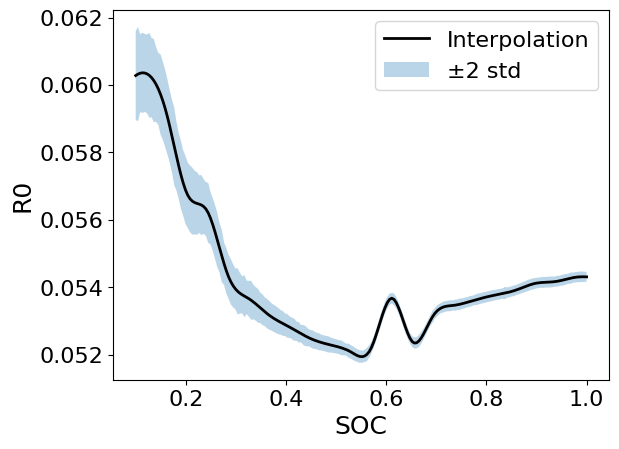

In [111]:
r0_samples = samples + interp_vals

r0_sample_mean = r0_samples.mean(dim=0)
r0_sample_std = r0_samples.std(dim=0)

import matplotlib.pyplot as plt

soc = test_soc.squeeze()

plt.plot(
    soc,
    interp_vals,
    'k',
    linewidth=2,
    label="Interpolation"
)

plt.fill_between(
    soc,
    (interp_vals - 2*r0_sample_std).numpy(),
    (interp_vals + 2*r0_sample_std).numpy(),
    alpha=0.3,
    label="±2 std"
)

plt.xlabel("SOC")
plt.ylabel("R0")


# plt.plot(soc, interp_vals + torch.sqrt(torch.detach(torch.diag(cov))), label="Theoretical std", color='blue')
# plt.plot(soc, interp_vals + r0_sample_std, '--', label="Empirical std", color='red')
# plt.plot(soc, interp_vals - torch.sqrt(torch.detach(torch.diag(cov))), color='blue')
# plt.plot(soc, interp_vals - r0_sample_std, '--', label="Empirical std", color='red')
plt.legend()

plt.legend()
plt.show()


In [112]:
# this is okay. but there is too much uncertainty in smoother regions.

# new implementation will take the gradient of the intepolation and use that to inform the scaling.
# get array of interpolated values, use scipyto differentiate.
def compute_roughness(interpolation, test_soc):
    """Compute second derivative (curvature) of interpolation"""
    # Get first derivative
    print("interpolation shape:", interpolation.shape)
    print("test_soc shape:", test_soc.shape)
    first_deriv = np.gradient(interpolation.numpy(), test_soc.numpy(), axis=0)
    
    # Get second derivative
    second_deriv = np.gradient(first_deriv, test_soc.numpy(), axis=0)
    
    # Roughness = absolute value of curvature
    roughness = 0.7 * torch.abs(torch.tensor(first_deriv, dtype=torch.float32)) + 0.7 * torch.abs(torch.tensor(second_deriv, dtype=torch.float32))
    
    return roughness


interp_r0 = lambda x: torch.tensor(interpolants["R0 [Ohm]"](x.numpy(), 25.0), dtype=torch.float32)

def sigma_roughness(test_soc):
    sigma_min = 5e-5
    sigma_max = 5e-4
    
    # Compute roughness of fixed interpolation
    # need to convert to 1d first:
    interpolation_1d = interp_r0(test_soc).squeeze(-1)
    test_soc_1d = test_soc.squeeze(-1)
    roughness = compute_roughness(interpolation=interpolation_1d, test_soc=test_soc_1d)
    
    # Normalise roughness to [0, 1]
    roughness_normalised = (roughness - roughness.min()) / (roughness.max() - roughness.min() + 1e-8)
    
    # High roughness → high uncertainty
    return sigma_min + (sigma_max - sigma_min) * roughness_normalised


def lengthscale_func(soc):
    return 0.10 + 0.1* torch.sigmoid(8 * (soc - 0.3))

kernel = GibbsKernel(input_dim=1, lengthscale_fn=lengthscale_func, variance=torch.tensor(var))
K = kernel.forward(test_soc) + noise * torch.eye(test_soc.shape[0]) # noise is added to the diagonal to ensure numerical stabilty & positive definiteness.

L = sigma_roughness(test_soc)



interpolation shape: torch.Size([200])
test_soc shape: torch.Size([200])


In [113]:
# helper code for plotting
def plot_matrices(R,K, suptitle="Covariance and correlation matrices for Gibbs kernel"):

    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    im0 = ax[0].imshow(R.detach().numpy(), cmap="viridis", vmin=0.0001, vmax=1,
               extent=[0, 1, 1, 0])  # extent maps axes to actual SOC values
    ax[0].set_title("Correlation matrix R")
    ax[0].set_xlabel("SOC"); ax[0].set_ylabel("SOC")
    fig.colorbar(im0, ax=ax[0], label="Correlation")

    im1 = ax[1].imshow(K.detach().numpy(), cmap="viridis")
    ax[1].set_title("Covariance Matrix K")
    ax[1].set_xlabel("SOC"); ax[1].set_ylabel("SOC")
    fig.colorbar(im1, ax=ax[1], label="Covariance")

    fig.suptitle(suptitle)
    plt.show()


def plot_uncertainty_gauss(cov, test_soc_points, interp_vals, title="Uncertainty in R0 prediction with Gibbs kernel"):

    samples = dist.MultivariateNormal(
        torch.zeros(len(test_soc_points)),
        covariance_matrix=cov,
    ).sample((len(test_soc_points),))

    r0_samples = samples + interp_vals

    r0_sample_mean = r0_samples.mean(dim=0)
    r0_sample_std = r0_samples.std(dim=0)

    import matplotlib.pyplot as plt

    soc = test_soc.squeeze()
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(
        soc,
        interp_vals,
        'k',
        linewidth=2,
        label="Interpolation"
    )

    ax.fill_between(
        soc,
        (interp_vals - 2*r0_sample_std).numpy(),
        (interp_vals + 2*r0_sample_std).numpy(),
        alpha=0.3,
        label="±2 std"
    )

    ax.set_xlabel("SOC")
    ax.set_ylabel("R0 [Ohm]")

    ax.legend()
    ax.set_title(title)
    return ax
    

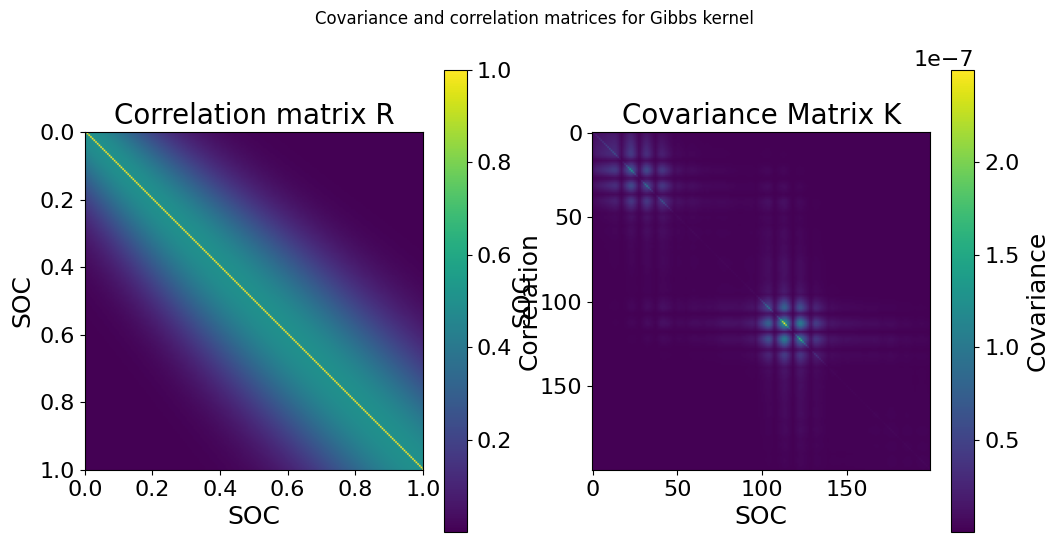

In [114]:
# plot K, L



R = K / torch.sqrt(torch.outer(torch.diag(K), torch.diag(K)))
K = torch.outer(L, L) * R
plot_matrices(R,K)

<Axes: title={'center': 'Uncertainty in R0 prediction with Gibbs kernel'}, xlabel='SOC', ylabel='R0 [Ohm]'>

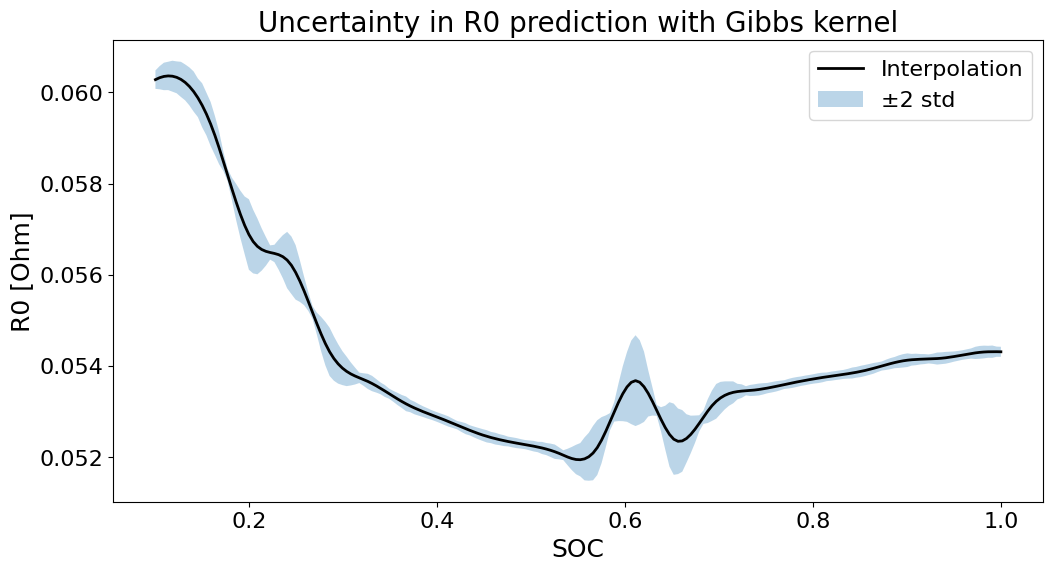

In [115]:
# R looks the same, K looks potentially more promising?

# visualise with gaussian uncertainty plot.
plot_uncertainty_gauss(torch.outer(L, L) * R, test_soc, interp_r0(test_soc).squeeze(-1))


In [116]:
# I like this more. The uncertainty is higher where the intepolation is rougher.
# one final point I would like to check is that should uncertainty be lower where known points lie..
# will try this as a final approach:


def sigma_roughness_with_known_points(test_soc, known_xs, known_ys, smooth_roughness=False, use_distance=True):
    sigma_min = 5e-5
    sigma_max = 5e-4
    
    # Compute roughness of fixed interpolation
    # need to convert to 1d first:
    interpolation_1d = interp_r0(test_soc).squeeze(-1)
    test_soc_1d = test_soc.squeeze(-1)
    roughness = compute_roughness(interpolation=interpolation_1d, test_soc=test_soc_1d)

    # Normalise roughness to [0, 1]
    roughness_normalised = (roughness - roughness.min()) / (roughness.max() - roughness.min() + 1e-8)
    # smooth roughness
    if smooth_roughness:
        from scipy.ndimage import gaussian_filter1d
        roughness_normalised = torch.tensor(gaussian_filter1d(roughness_normalised.detach().numpy(), sigma=3.0))
    
    # High roughness → high uncertainty

    # add in distance to known point component. This will reduce uncertainty near known points.
    known_points = torch.stack([known_xs, known_ys], dim=1)  # Shape: (n_known, 2)
    test_points = torch.stack([test_soc.squeeze(), interpolation_1d], dim=1)  # Shape: (200, 2)

    if not use_distance:
        return sigma_min + (sigma_max - sigma_min) * roughness_normalised
    distances = torch.cdist(test_points.float(), known_points.float())  # Shape: (200, n_known)

    min_distance = distances.min(dim=1).values
    distance_norm = min_distance / (min_distance.max() + 1e-8)
    
    combined = roughness_normalised + distance_norm  # or weighted: 0.6*rough + 0.4*distance
    combined_norm = combined / (combined.max() + 1e-8)
    
    return sigma_min + (sigma_max - sigma_min) * combined_norm

interpolation shape: torch.Size([200])
test_soc shape: torch.Size([200])


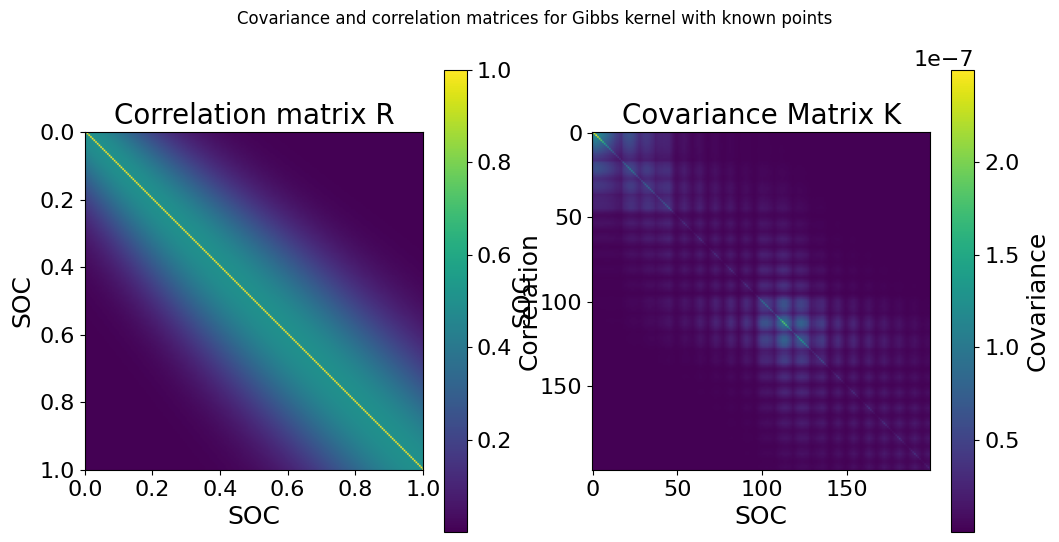

In [117]:
L = sigma_roughness_with_known_points(test_soc, known_xs=X, known_ys=Y)
K = kernel.forward(test_soc) + noise * torch.eye(test_soc.shape[0]) # noise is added to the diagonal to ensure numerical stabilty & positive definiteness.
R = K / torch.sqrt(torch.outer(torch.diag(K), torch.diag(K)))
K = torch.outer(L, L) * R

plot_matrices(R,K, suptitle="Covariance and correlation matrices for Gibbs kernel with known points")

<Axes: title={'center': 'Uncertainty in R0 prediction with Gibbs kernel'}, xlabel='SOC', ylabel='R0 [Ohm]'>

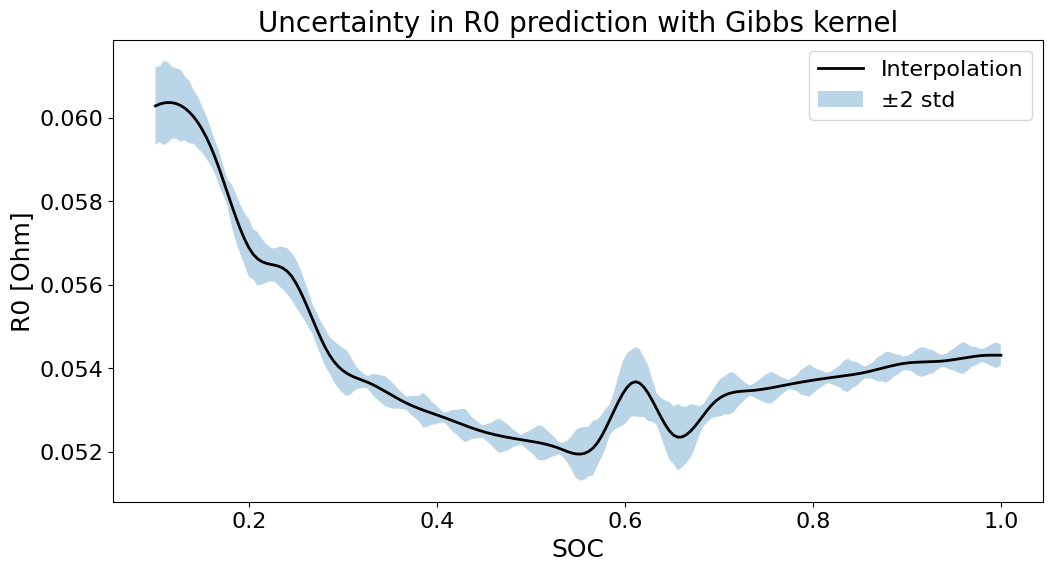

In [118]:
# This looks promising.

plot_uncertainty_gauss(torch.outer(L, L) * R, test_soc, interp_r0(test_soc).squeeze(-1))


interpolation shape: torch.Size([200])
test_soc shape: torch.Size([200])


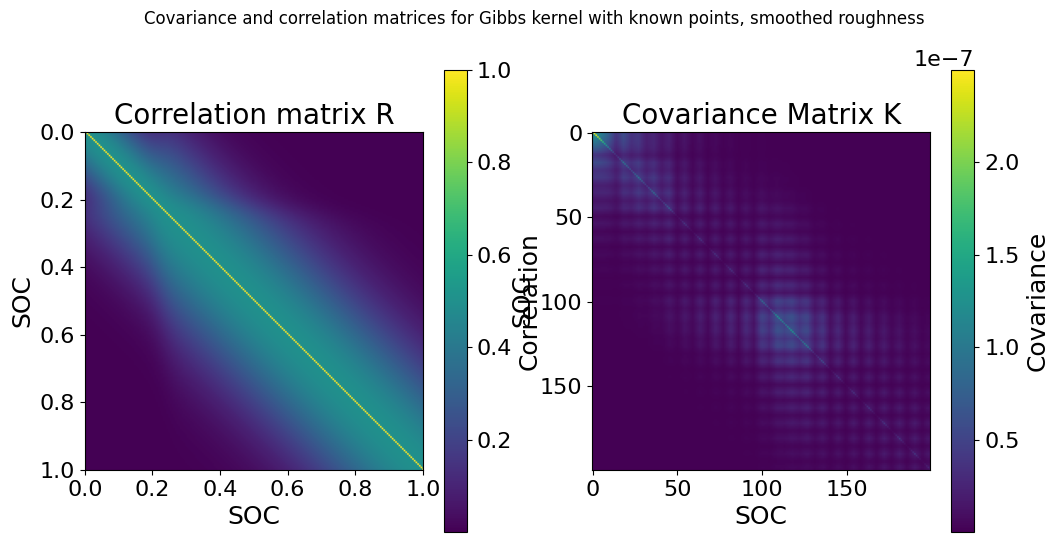

In [119]:
# looks good. An issue might be that there is too much noise in the roughness measure, due to the wide spacings in the interpolation.
# will smooth the roughness measure.
from scipy.ndimage import gaussian_filter1d


def lengthscale_func(soc):
    return 0.10 + 0.1* torch.sigmoid(50 * (soc - 0.3))

var = 0.00000001

kernel = GibbsKernel(input_dim=1, lengthscale_fn=lengthscale_func, variance=torch.tensor(var))


L_smooth = sigma_roughness_with_known_points(test_soc, known_xs=X, known_ys=Y, smooth_roughness=True)
K = kernel.forward(test_soc) + noise * torch.eye(test_soc.shape[0]) # noise is added to the diagonal to ensure numerical stabilty & positive definiteness.
R = K / torch.sqrt(torch.outer(torch.diag(K), torch.diag(K)))
K = torch.outer(L_smooth, L_smooth) * R
plot_matrices(R,K, suptitle="Covariance and correlation matrices for Gibbs kernel with known points, smoothed roughness")


interpolation shape: torch.Size([200])
test_soc shape: torch.Size([200])


Text(0.5, 0.9, 'Kernel: Matern52, variance=1e-08, lengthscale=0.5, noise=1e-08')

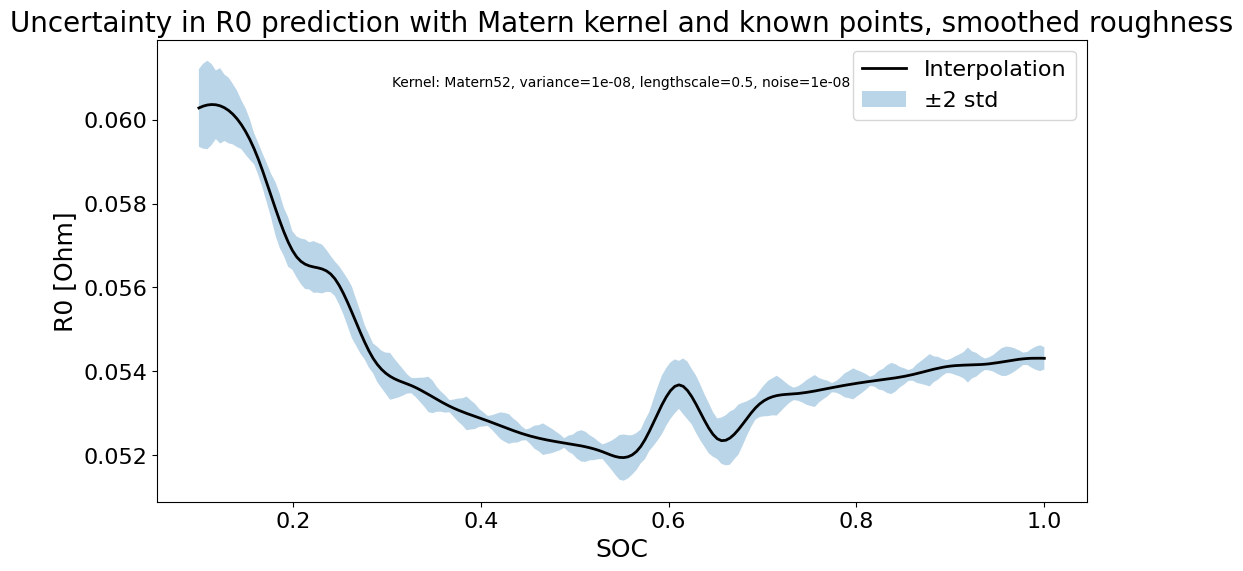

In [120]:
# try this all with a matern kernel to see if it is better than the gibbs kernel.
mat_kernel = gp.kernels.Matern52(input_dim=1, variance=torch.tensor(var), lengthscale=torch.tensor(lengthscale))
K = mat_kernel.forward(test_soc) + noise * torch.eye(test_soc.shape[0]) # noise is added to the diagonal to ensure numerical stabilty & positive definiteness.
R = K / torch.sqrt(torch.outer(torch.diag(K), torch.diag(K)))
L = sigma_roughness_with_known_points(test_soc, known_xs=X, known_ys=Y, smooth_roughness=True)

ax = plot_uncertainty_gauss(torch.outer(L, L) * R, test_soc, interp_r0(test_soc).squeeze(-1), title="Uncertainty in R0 prediction with Matern kernel and known points, smoothed roughness")
ax.text(0.5, 0.9, f"Kernel: Matern52, variance={var}, lengthscale={lengthscale}, noise={noise}", transform=ax.transAxes, ha='center', fontsize=10)
    

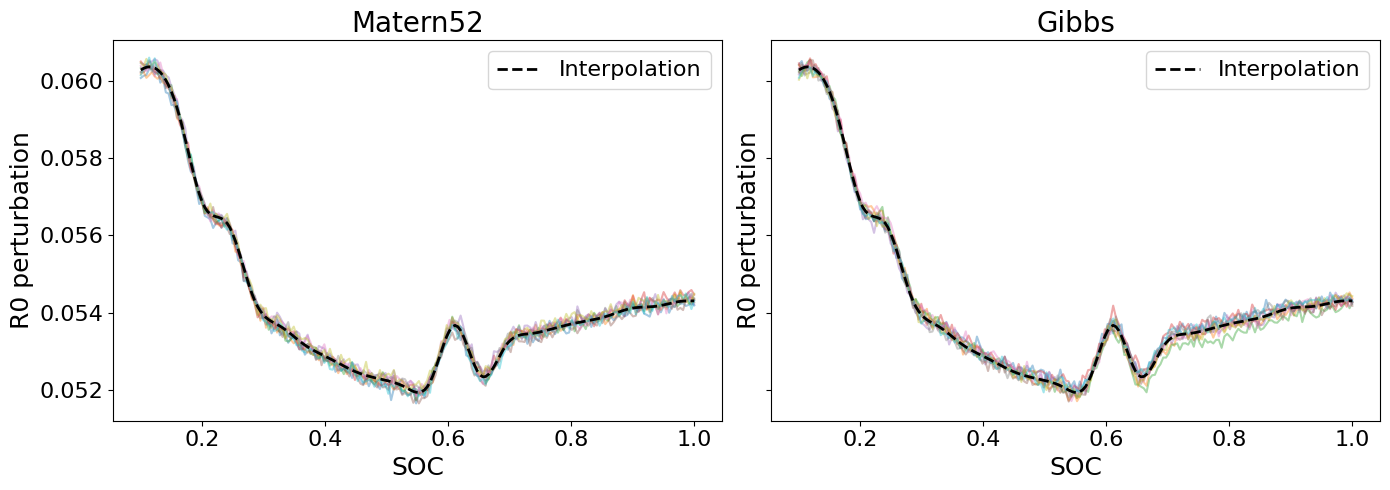

In [121]:
# there is very little qualitiative difference because the activation function is dominating the uncertainty, as opposed to the gibbs kernel.

cov_matern = mat_kernel.forward(test_soc) + noise * torch.eye(test_soc.shape[0]) # noise is added to the diagonal to ensure numerical stabilty & positive definiteness.
cov_gibbs = kernel.forward(test_soc) + noise * torch.eye(test_soc.shape[0]) # noise is added to the diagonal to ensure numerical stabilty & positive definiteness.

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Sample from Matern
samples_matern = dist.MultivariateNormal(
    torch.zeros(len(test_soc)), covariance_matrix=cov_matern
).sample((10,))

# Sample from Gibbs
samples_gibbs = dist.MultivariateNormal(
    torch.zeros(len(test_soc)), covariance_matrix=cov_gibbs
).sample((10,))

interpolation = interp_r0(test_soc).squeeze(-1)

for ax, samples, title in zip(axes, 
                               [samples_matern, samples_gibbs], 
                               ['Matern52', 'Gibbs']):
    ax.plot(test_soc.numpy(), interpolation.numpy().reshape(-1, 1) + samples.T.detach().numpy(), alpha=0.4)
    ax.plot(test_soc.numpy(), interpolation.numpy(), 'k--', linewidth=2, label='Interpolation')
    ax.set_title(title)
    ax.set_xlabel('SOC')
    ax.set_ylabel('R0 perturbation')
    ax.legend()

plt.tight_layout()

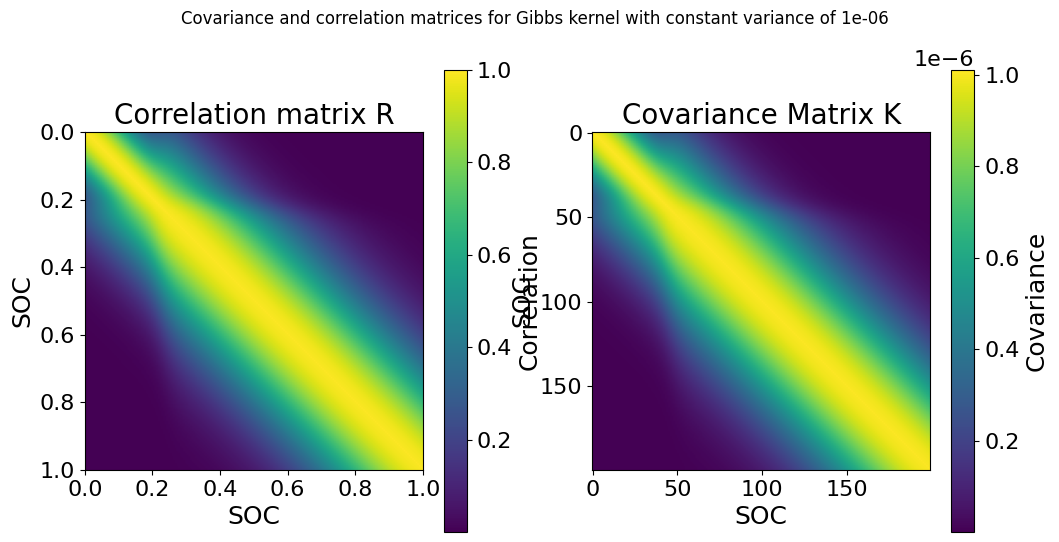

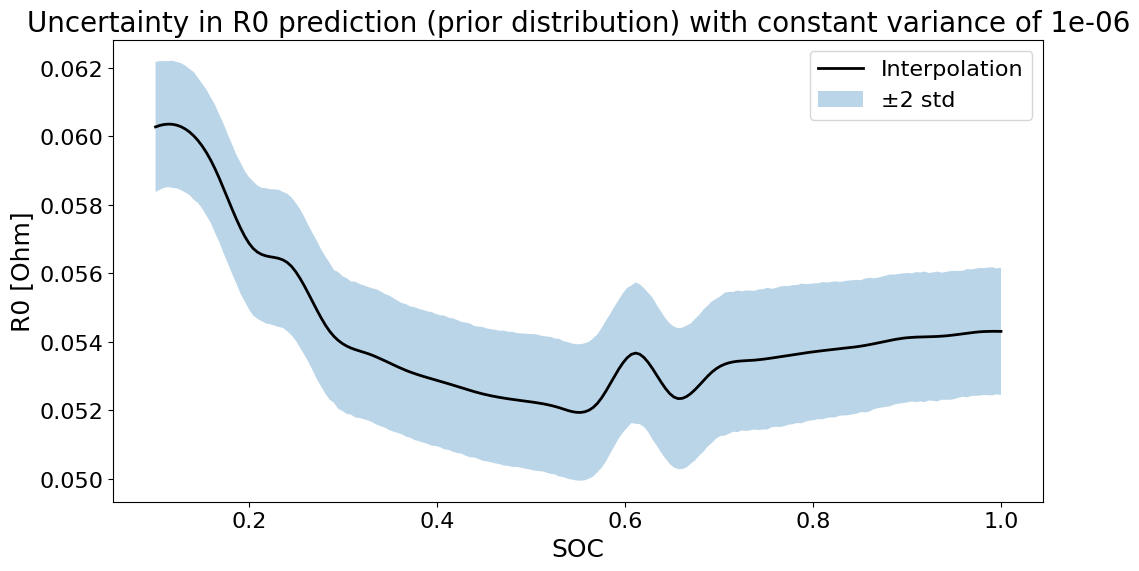

In [122]:
# try with a kernel that is less dominated by the activation function, and is more sensitive to the initial kernel.
# this is done by increasing the variance of the kernel, which will reduce the overall uncertainty and make the kernel more sensitive to the lengthscale function.
variance_increased = 1e-6
def lengthscale_func(soc):
    return 0.10 + 0.1* torch.sigmoid(50 * (soc - 0.3))
kernel_increased = GibbsKernel(input_dim=1, lengthscale_fn=lengthscale_func, variance=torch.tensor(variance_increased))
K = kernel_increased.forward(test_soc) + noise * torch.eye(test_soc.shape[0]) # noise is added to the diagonal to ensure numerical stabilty & positive definiteness.
R = K / torch.sqrt(torch.outer(torch.diag(K), torch.diag(K)))
plot_matrices(R,K, suptitle=f"Covariance and correlation matrices for Gibbs kernel with constant variance of {variance_increased}")
plot_uncertainty_gauss(K, test_soc, interp_r0(test_soc).squeeze(-1), title=f"Uncertainty in R0 prediction (prior distribution) with constant variance of {variance_increased}")
plt.savefig("R0_uncertainty.pdf", dpi=300)

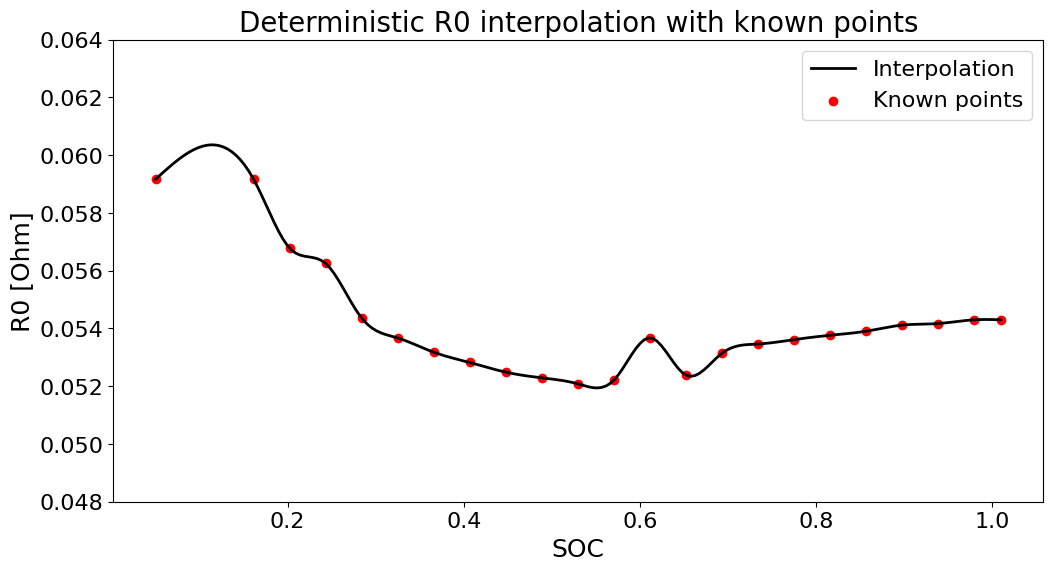

In [127]:
3 # plot r0 without any uncertainty, just the interpolation and the known points.
plt.figure(figsize=(12, 6))
test_soc = torch.linspace(0.05, 1.01, 200).reshape(-1, 1)
plt.plot(test_soc.numpy(), interp_r0(test_soc).squeeze(-1).numpy(), 'k', linewidth=2, label="Interpolation")
plt.scatter(X.numpy(), Y.numpy(), color='red', label='Known points')
plt.xlabel("SOC")
plt.ylabel("R0 [Ohm]")
plt.legend()
plt.ylim(0.048,0.064)
plt.title(f"Deterministic R0 interpolation with known points")
plt.savefig("r0_interpolation.pdf", dpi=300)

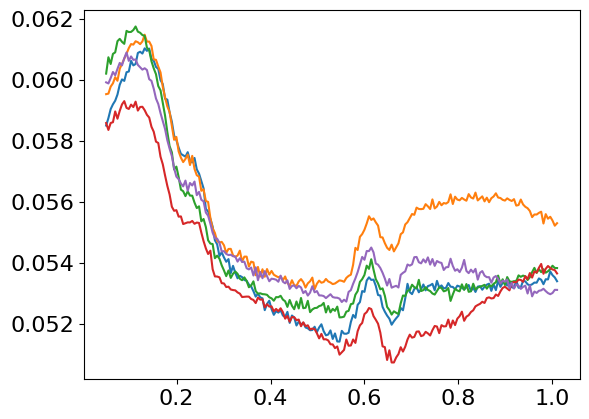

In [124]:
# try plotting a few samples:

test_soc_points = test_soc.squeeze(-1)
interp_vals = interp_r0(test_soc).squeeze(-1)

samples = dist.MultivariateNormal(
    torch.zeros(len(test_soc_points)),
    covariance_matrix=K,
).sample((5,))

for s in samples:
    plt.plot(test_soc_points, interp_vals + s)


In [125]:
# apparently all I have been plotting is the prior distribution.

# need to condition it on known points. This is done by using the GPRegression model in pyro, and conditioning on the known points.


from pyro.contrib.gp.models import GPRegression
train_X = X.reshape(-1, 1)
train_Y = torch.zeros_like(train_X).reshape(-1)  # Assuming zero mean for the GP prior
# make them all float64 for consistency with the GPRegression model
train_X = train_X.double()
train_Y = train_Y.double()
test_soc = test_soc.double()
print(f"{train_X.shape=}, {train_Y.shape=}, {K.shape=}, {test_soc.shape=}")

def lengthscale_func(soc):
    return 0.10 + 0.1* torch.sigmoid(50 * (soc - 0.3))

variance = 1e-5
noise = 1e-5

kernel = GibbsKernel(input_dim=1, lengthscale_fn=lengthscale_func, variance=torch.tensor(variance, dtype=torch.float64))
gp = GPRegression(train_X, train_Y, kernel, noise=torch.tensor(noise))

# check dtypes of train_X, train_Y, test_soc
print(f"{train_X.dtype=}, {train_Y.dtype=}, {test_soc.dtype=}")


mean,cov = gp(test_soc, full_cov=True, noiseless=False)

std = torch.sqrt(torch.diag(cov))

soc = test_soc.squeeze()


ys = interp_r0(test_soc).squeeze(-1) + mean.detach().squeeze()




train_X.shape=torch.Size([23, 1]), train_Y.shape=torch.Size([23]), K.shape=torch.Size([200, 200]), test_soc.shape=torch.Size([200, 1])
train_X.dtype=torch.float64, train_Y.dtype=torch.float64, test_soc.dtype=torch.float64


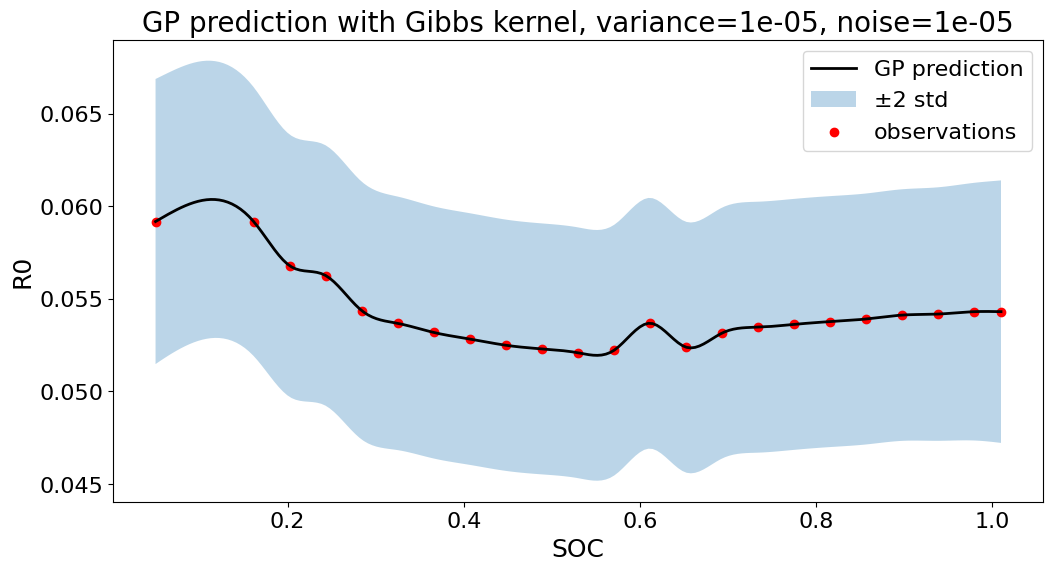

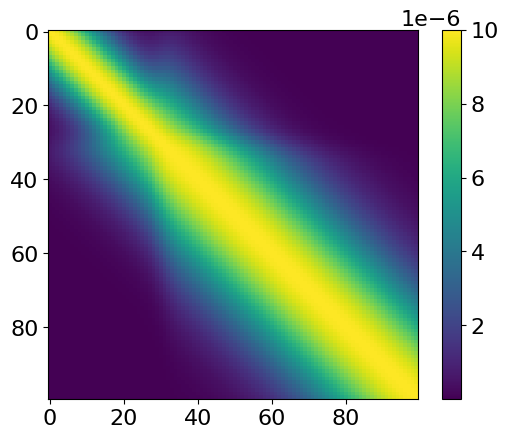

In [126]:
plt.figure(figsize=(12,6))
plt.plot(
    soc,
    ys,
    'k',
    linewidth=2,
    label="GP prediction"
)
plt.fill_between(
    soc,
    (ys - 2*std).detach(),
    (ys + 2*std).detach(),
    alpha=0.3,
    label="±2 std"
)

plt.scatter(
    X.squeeze(),
    Y.squeeze(),
    color="red",
    label="observations"
)

plt.legend()
plt.xlabel("SOC")
plt.ylabel("R0")
plt.title(f"GP prediction with Gibbs kernel, variance={variance}, noise={noise}")
plt.show()

x1 = torch.linspace(0, 1, 100).reshape(-1,1)

K = kernel(x1, x1)

plt.imshow(K.detach())
plt.colorbar()
plt.show()